<a href="https://colab.research.google.com/github/vinakandekar05/Fake_genuine_product_svm/blob/main/feke_genuine_product_svm_cs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import pandas as pd
df = pd.read_csv('/content/fake_genuine_product_svm (1).csv')

In [ ]:
df.head()

,texture_score,shape_irregularity,material_quality,brand_rating,price_deviation,is_genuine
0,0.49,4.38,9.75,3.8,0.03,1
1,2.89,0.21,6.45,3.9,0.40,1
2,7.21,4.90,3.20,1.6,0.81,0
3,0.22,3.79,7.90,3.1,0.22,1
4,2.06,4.47,0.18,1.2,0.20,0


In [ ]:
X = df[['texture_score', 'shape_irregularity', 'material_quality', 'brand_rating', 'price_deviation']]
y = df['is_genuine']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

In [ ]:
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)
model.fit(X_train, y_train)

SVC(C=1)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[34  0]
 [ 2 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        34
           1       1.00      0.93      0.96        29

    accuracy                           0.97        63
   macro avg       0.97      0.97      0.97        63
weighted avg       0.97      0.97      0.97        63



In [ ]:
X_vis = df[['texture_score', 'price_deviation']]
y_vis = df['is_genuine']

In [ ]:
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)


In [ ]:
model_vis = SVC(kernel="rbf", C=1, gamma="scale")
model_vis.fit(X_vis_scaled, y_vis)

SVC(C=1)

In [ ]:
import numpy as np

xx, yy = np.meshgrid(
    np.linspace(X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1, 300),
    np.linspace(X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1, 300)
)

In [ ]:
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


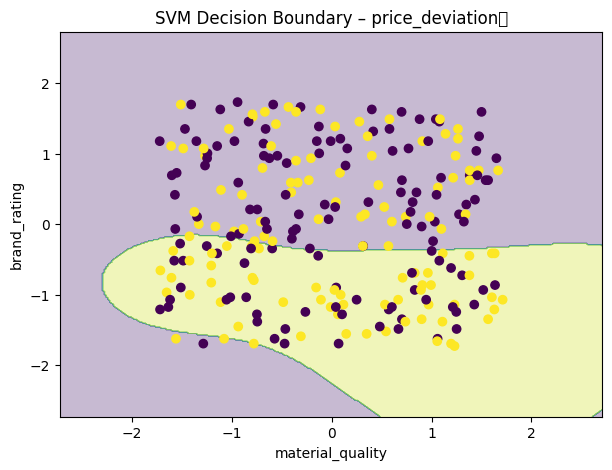

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis_scaled[:,0], X_vis_scaled[:,1], c=y_vis)
plt.xlabel("material_quality")
plt.ylabel("brand_rating")
plt.title("SVM Decision Boundary – price_deviation	")
plt.show()

In [ ]:

new_product_data = pd.DataFrame({
    "texture_score": [0.5, 2.0],
    "shape_irregularity": [1.5, 0.8],
    "material_quality": [9.0, 5.0],
    "brand_rating": [4.0, 3.5],
    "price_deviation": [0.1, 0.3]
})

new_scaled = scaler.transform(new_product_data)
predictions = model.predict(new_scaled)

print("Predictions (1 = Genuine, 0 = Fake):", predictions)
print("Scaled new product data:\n", new_scaled)
print("Predictions:\n", predictions)

Predictions (1 = Genuine, 0 = Fake): [1 1]
Scaled new product data:
 [[-1.55770584 -0.79209922  1.43994899  0.85702488 -1.38365666]
 [-1.0375273  -1.27265863  0.0926283   0.41958874 -0.69189751]]
Predictions:
 [1 1]
